# Import Libraries

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files
print("All Libraries Imported")

All Libraries Imported


# Datasets

In [31]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

# Helper to find the latest version of a file name in the uploaded dict
def get_latest(filename):
    matches = [k for k in uploaded.keys() if filename.split('.')[0] in k]
    return matches[-1] if matches else filename

# Loading the datasets using the latest uploaded names
df = pd.read_csv(get_latest('dataset.csv'))

if any('symptom_Description' in k for k in uploaded):
    df_desc = pd.read_csv(get_latest('symptom_Description.csv'))
    print(f"✅ {get_latest('symptom_Description.csv')} loaded")

if any('symptom_precaution' in k for k in uploaded):
    df_prec = pd.read_csv(get_latest('symptom_precaution.csv'))
    print(f"✅ {get_latest('symptom_precaution.csv')} loaded")

display(df.head())

Saving dataset.csv to dataset (1).csv
Saving symptom_Description.csv to symptom_Description (1).csv
Saving symptom_precaution.csv to symptom_precaution (1).csv
Saving Symptom-severity.csv to Symptom-severity (1).csv
✅ symptom_Description (1).csv loaded
✅ symptom_precaution (1).csv loaded


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
print(f'Dataset Shape: {df.shape}')
print('\nMissing values per column:')
print(df.isnull().sum())

# Count unique symptoms across all symptom columns
symptoms = pd.unique(df.iloc[:, 1:].values.ravel('K'))
symptoms = [s for s in symptoms if str(s) != 'nan']
print(f'\nTotal Unique Symptoms: {len(symptoms)}')

# Check target distribution
print('\nDisease Distribution (Top 10):')
print(df['Disease'].value_counts().head(10))

Dataset Shape: (4920, 18)

Missing values per column:
Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

Total Unique Symptoms: 131

Disease Distribution (Top 10):
Disease
Fungal infection       120
Allergy                120
GERD                   120
Chronic cholestasis    120
Drug Reaction          120
Peptic ulcer diseae    120
AIDS                   120
Diabetes               120
Gastroenteritis        120
Bronchial Asthma       120
Name: count, dtype: int64


# Cleaning Datasets

In [33]:
df.columns = df.columns.str.strip()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

# Ensure df_desc and df_prec are defined before cleaning
# You must load these files similar to how you loaded 'df'
if 'df_desc' in locals() or 'df_desc' in globals():
    df_desc.columns = df_desc.columns.str.strip()
    description_map = dict(zip(df_desc["Disease"], df_desc["Description"]))
else:
    print("Warning: df_desc not found. Please load the description dataset.")
    description_map = {}

if 'df_prec' in locals() or 'df_prec' in globals():
    df_prec.columns = df_prec.columns.str.strip()
    precaution_map = {
        row["Disease"]: [
            row["Precaution_1"],
            row["Precaution_2"],
            row["Precaution_3"],
            row["Precaution_4"],
        ]
        for _, row in df_prec.iterrows()
    }
else:
    print("Warning: df_prec not found. Please load the precaution dataset.")
    precaution_map = {}

description_map, precaution_map

({'Drug Reaction': 'An adverse drug reaction (ADR) is an injury caused by taking medication. ADRs may occur following a single dose or prolonged administration of a drug or result from the combination of two or more drugs.',
  'Malaria': 'An infectious disease caused by protozoan parasites from the Plasmodium family that can be transmitted by the bite of the Anopheles mosquito or by a contaminated needle or transfusion. Falciparum malaria is the most deadly type.',
  'Allergy': "An allergy is an immune system response to a foreign substance that's not typically harmful to your body.They can include certain foods, pollen, or pet dander. Your immune system's job is to keep you healthy by fighting harmful pathogens.",
  'Hypothyroidism': 'Hypothyroidism, also called underactive thyroid or low thyroid, is a disorder of the endocrine system in which the thyroid gland does not produce enough thyroid hormone.',
  'Psoriasis': "Psoriasis is a common skin disorder that forms thick, red, bumpy p

In [34]:
from sklearn.feature_selection import mutual_info_classif

# 1. Create a binary indicator matrix for all unique symptoms
# Get all unique symptoms excluding NaN
all_symptoms = pd.unique(df.iloc[:, 1:].values.ravel('K'))
all_symptoms = [str(s).strip() for s in all_symptoms if str(s) != 'nan']
unique_symptoms = sorted(list(set(all_symptoms)))

# Initialize binary dataframe
X_binary = pd.DataFrame(0, index=df.index, columns=unique_symptoms)

# Fill the matrix
for i in range(len(df)):
    row_symptoms = [str(s).strip() for s in df.iloc[i, 1:].dropna()]
    X_binary.loc[i, row_symptoms] = 1

y_labels = df['Disease'].str.strip()

# 2. Calculate Mutual Information scores
mi_scores = mutual_info_classif(X_binary, y_labels, discrete_features=True, random_state=42)

mi_results = pd.DataFrame({
    'Symptom': unique_symptoms,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("✅ Mutual Information scores calculated.")
display(mi_results.head(10))

✅ Mutual Information scores calculated.


,Symptom,MI_Score
41,fatigue,0.586290
121,vomiting,0.573650
45,high_fever,0.531205
60,loss_of_appetite,0.507258
71,nausea,0.499212
44,headache,0.490115
0,abdominal_pain,0.474899
130,yellowish_skin,0.440699
129,yellowing_of_eyes,0.431638
19,chills,0.411154


In [35]:
# 3. Finalize DMICF: Select top K causal features
K_features = 30
selected_features = mi_results.head(K_features)['Symptom'].tolist()

# Create the refined dataset using only selected symptoms
X_dmicf = X_binary[selected_features]

print(f"✅ Feature Selection Complete.")
print(f"Original features: {X_binary.shape[1]}")
print(f"Selected features: {X_dmicf.shape[1]}")
print("\nTop 10 Selected Symptoms:")
print(selected_features[:10])

display(X_dmicf.head())


✅ Feature Selection Complete.
Original features: 131
Selected features: 30

Top 10 Selected Symptoms:
['fatigue', 'vomiting', 'high_fever', 'loss_of_appetite', 'nausea', 'headache', 'abdominal_pain', 'yellowish_skin', 'yellowing_of_eyes', 'chills']


,fatigue,vomiting,high_fever,loss_of_appetite,nausea,headache,abdominal_pain,yellowish_skin,yellowing_of_eyes,chills,...,irritability,excessive_hunger,weight_loss,lethargy,breathlessness,mild_fever,phlegm,swelled_lymph_nodes,loss_of_balance,blurred_and_distorted_vision
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


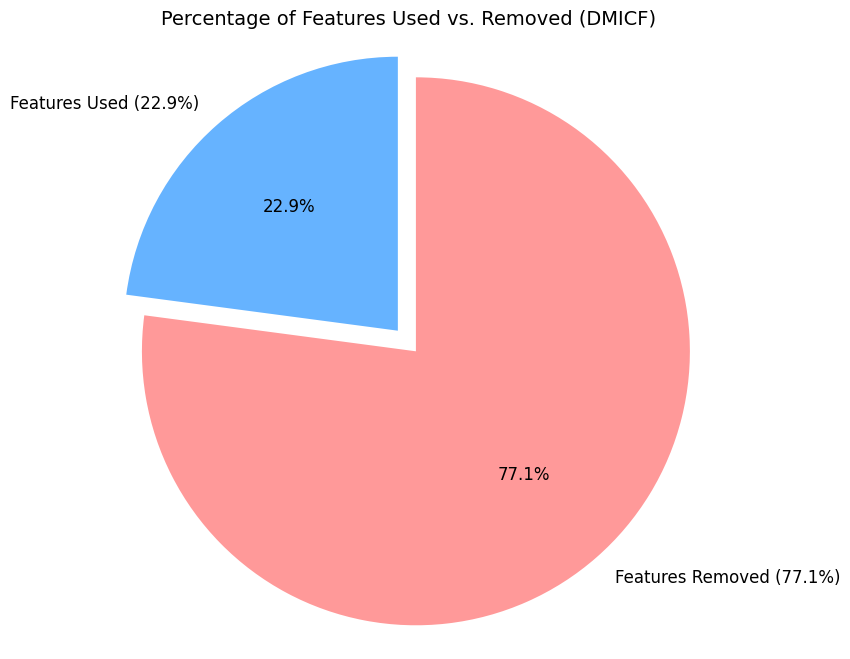

In [58]:
import matplotlib.pyplot as plt

original_features = X_binary.shape[1]
selected_features_count = X_dmicf.shape[1]
removed_features_count = original_features - selected_features_count

percentage_used = (selected_features_count / original_features) * 100
percentage_removed = (removed_features_count / original_features) * 100

labels = [f'Features Used ({percentage_used:.1f}%)', f'Features Removed ({percentage_removed:.1f}%)']
sizes = [percentage_used, percentage_removed]
colors = ['#66b3ff', '#ff9999']
explode = (0.1, 0)  # Explode the 'Features Used' slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Percentage of Features Used vs. Removed (DMICF)', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare target variable
y = df['Disease'].str.strip()

# Split the reduced dataset
X_train_dm, X_test_dm, y_train_dm, y_test_dm = train_test_split(
    X_dmicf, y, test_size=0.2, random_state=42
)

# Train Models
knn_dm = KNeighborsClassifier(n_neighbors=5)
knn_dm.fit(X_train_dm, y_train_dm)
dt_dm = DecisionTreeClassifier(random_state=42)
dt_dm.fit(X_train_dm, y_train_dm)

# Evaluate
knn_acc = accuracy_score(y_test_dm, knn_dm.predict(X_test_dm))
dt_acc = accuracy_score(y_test_dm, dt_dm.predict(X_test_dm))

print(f"KNN Accuracy (Reduced Features): {knn_acc:.4f}")
print(f"Decision Tree Accuracy (Reduced Features): {dt_acc:.4f}")


KNN Accuracy (Reduced Features): 0.9004
Decision Tree Accuracy (Reduced Features): 0.8933


In [37]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train Random Forest Model
rf_dm = RandomForestClassifier(random_state=42)
rf_dm.fit(X_train_dm, y_train_dm)

# Train Gradient Boosting Model
gb_dm = GradientBoostingClassifier(random_state=42)
gb_dm.fit(X_train_dm, y_train_dm)

# Evaluate
rf_acc = accuracy_score(y_test_dm, rf_dm.predict(X_test_dm))
gb_acc = accuracy_score(y_test_dm, gb_dm.predict(X_test_dm))

print(f"Random Forest Accuracy (Reduced Features): {rf_acc:.4f}")
print(f"Gradient Boosting Accuracy (Reduced Features): {gb_acc:.4f}")

Random Forest Accuracy (Reduced Features): 0.8933
Gradient Boosting Accuracy (Reduced Features): 0.8933


# Mapping

In [38]:
if any('Symptom-severity' in k for k in uploaded):
    df_severity = pd.read_csv(get_latest('Symptom-severity.csv'))
    print(f"✅ {get_latest('Symptom-severity.csv')} loaded")
else:
    print("Warning: Symptom-severity.csv not found. Please upload the file.")
    df_severity = pd.DataFrame(columns=["Symptom", "weight"]) # Create an empty DataFrame to avoid further errors

severity_map = dict(zip(df_severity["Symptom"], df_severity["weight"]))
severity_map

✅ Symptom-severity (1).csv loaded


{'itching': 1,
 'skin_rash': 3,
 'nodal_skin_eruptions': 4,
 'continuous_sneezing': 4,
 'shivering': 5,
 'chills': 3,
 'joint_pain': 3,
 'stomach_pain': 5,
 'acidity': 3,
 'ulcers_on_tongue': 4,
 'muscle_wasting': 3,
 'vomiting': 5,
 'burning_micturition': 6,
 'spotting_urination': 6,
 'fatigue': 4,
 'weight_gain': 3,
 'anxiety': 4,
 'cold_hands_and_feets': 5,
 'mood_swings': 3,
 'weight_loss': 3,
 'restlessness': 5,
 'lethargy': 2,
 'patches_in_throat': 6,
 'irregular_sugar_level': 5,
 'cough': 4,
 'high_fever': 7,
 'sunken_eyes': 3,
 'breathlessness': 4,
 'sweating': 3,
 'dehydration': 4,
 'indigestion': 5,
 'headache': 3,
 'yellowish_skin': 3,
 'dark_urine': 4,
 'nausea': 5,
 'loss_of_appetite': 4,
 'pain_behind_the_eyes': 4,
 'back_pain': 3,
 'constipation': 4,
 'abdominal_pain': 4,
 'diarrhoea': 6,
 'mild_fever': 5,
 'yellow_urine': 4,
 'yellowing_of_eyes': 4,
 'acute_liver_failure': 6,
 'fluid_overload': 4,
 'swelling_of_stomach': 7,
 'swelled_lymph_nodes': 6,
 'malaise': 6,
 'bl

# Replace Symptoms with Severity Values

In [39]:
df_filled = df.copy()

symptom_cols = df_filled.columns[1:]

for col in symptom_cols:
    df_filled[col] = df_filled[col].map(severity_map).fillna(0)

df_filled.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,1,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Fungal infection,3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Fungal infection,1,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Fungal infection,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Fungal infection,1,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Encode Disease Label

In [40]:
le = LabelEncoder()
df_filled["Disease"] = le.fit_transform(df_filled["Disease"])

y = df_filled["Disease"]
X = df_filled.drop("Disease", axis=1)

le.classes_

array(['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne',
       'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma',
       'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis',
       'Common Cold', 'Dengue', 'Diabetes',
       'Dimorphic hemmorhoids(piles)', 'Drug Reaction',
       'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Hypertension', 'Hyperthyroidism', 'Hypoglycemia',
       'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine',
       'Osteoarthristis', 'Paralysis (brain hemorrhage)',
       'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis',
       'Typhoid', 'Urinary tract infection', 'Varicose veins',
       'hepatitis A'], dtype=object)

## Model Training with Different Data Chunk Sizes

In [41]:
def train_and_evaluate(X_data, y_data, test_size=0.2, random_state=42):
    X_train_chunk, X_test_chunk, y_train_chunk, y_test_chunk = train_test_split(
        X_data, y_data, test_size=test_size, random_state=random_state
    )

    # Train k-NN
    knn_chunk = KNeighborsClassifier(n_neighbors=10)
    knn_chunk.fit(X_train_chunk, y_train_chunk)
    knn_pred_chunk = knn_chunk.predict(X_test_chunk)
    knn_acc_chunk = accuracy_score(y_test_chunk, knn_pred_chunk)

    # Train Decision Tree
    dt_chunk = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=random_state)
    dt_chunk.fit(X_train_chunk, y_train_chunk)
    dt_pred_chunk = dt_chunk.predict(X_test_chunk)
    dt_acc_chunk = accuracy_score(y_test_chunk, dt_pred_chunk)

    return knn_acc_chunk, dt_acc_chunk

print("Helper function `train_and_evaluate` defined.")

Helper function `train_and_evaluate` defined.


### Training on 4920 entries (Full Dataset)

In [42]:
knn_acc_4920, dt_acc_4920 = train_and_evaluate(X, y)
print(f"Full Dataset (4920 entries) - KNN Accuracy: {knn_acc_4920:.4f}")
print(f"Full Dataset (4920 entries) - Decision Tree Accuracy: {dt_acc_4920:.4f}")

Full Dataset (4920 entries) - KNN Accuracy: 0.9837
Full Dataset (4920 entries) - Decision Tree Accuracy: 0.9949


### Training on 2460 entries

In [43]:
# Sample 2460 entries from the full dataset
df_2460 = df_filled.sample(n=2460, random_state=42)
X_2460 = df_2460.drop("Disease", axis=1)
y_2460 = df_2460["Disease"]

knn_acc_2460, dt_acc_2460 = train_and_evaluate(X_2460, y_2460)
print(f"2460 Entries - KNN Accuracy: {knn_acc_2460:.4f}")
print(f"2460 Entries - Decision Tree Accuracy: {dt_acc_2460:.4f}")

2460 Entries - KNN Accuracy: 0.9573
2460 Entries - Decision Tree Accuracy: 0.9797


### Training on 1040 entries

In [44]:
# Sample 1040 entries from the full dataset
df_1040 = df_filled.sample(n=1040, random_state=42)
X_1040 = df_1040.drop("Disease", axis=1)
y_1040 = df_1040["Disease"]

knn_acc_1040, dt_acc_1040 = train_and_evaluate(X_1040, y_1040)
print(f"1040 Entries - KNN Accuracy: {knn_acc_1040:.4f}")
print(f"1040 Entries - Decision Tree Accuracy: {dt_acc_1040:.4f}")

1040 Entries - KNN Accuracy: 0.9183
1040 Entries - Decision Tree Accuracy: 0.9952


### Comparison of Accuracies across Data Chunk Sizes

,Chunk Size,KNN Accuracy,Decision Tree Accuracy
0,4920,0.983740,0.994919
1,2460,0.957317,0.979675
2,1040,0.918269,0.995192


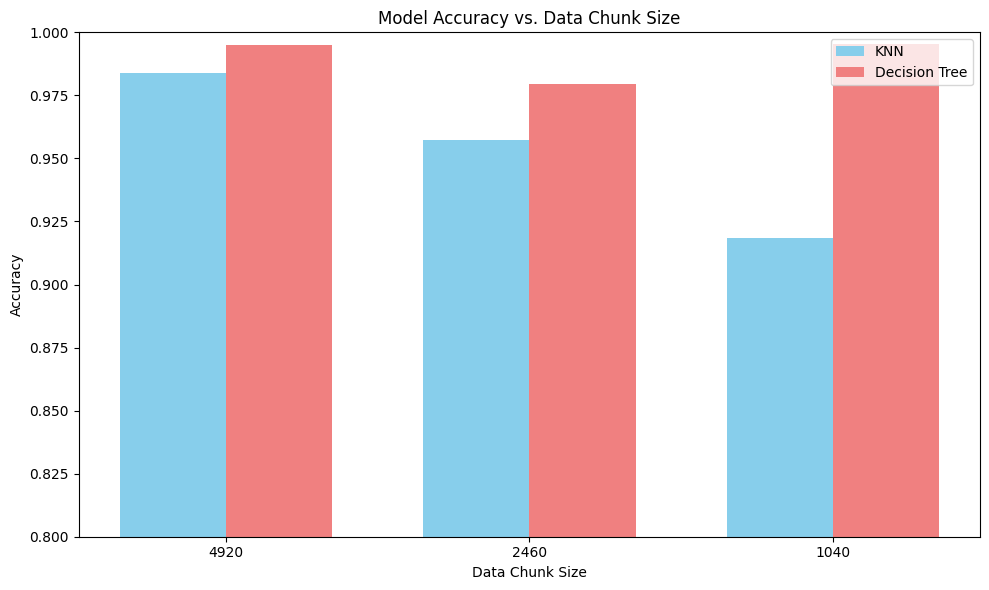

In [45]:
chunk_sizes = [4920, 2460, 1040]
knn_accuracies = [knn_acc_4920, knn_acc_2460, knn_acc_1040]
dt_accuracies = [dt_acc_4920, dt_acc_2460, dt_acc_1040]

comparison_df = pd.DataFrame({
    'Chunk Size': chunk_sizes,
    'KNN Accuracy': knn_accuracies,
    'Decision Tree Accuracy': dt_accuracies
})

display(comparison_df)

plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(chunk_sizes))

plt.bar(index, knn_accuracies, bar_width, label='KNN', color='skyblue')
plt.bar(index + bar_width, dt_accuracies, bar_width, label='Decision Tree', color='lightcoral')

plt.xlabel('Data Chunk Size')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs. Data Chunk Size')
plt.xticks(index + bar_width / 2, chunk_sizes)
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# Model Error

/tmp/ipykernel_4388/713649388.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["KNN Errors", "Decision Tree Errors", "Random Forest Errors", "Gradient Boosting Errors"], y=[knn_errors, dt_errors, rf_errors, gb_errors], palette="rocket")


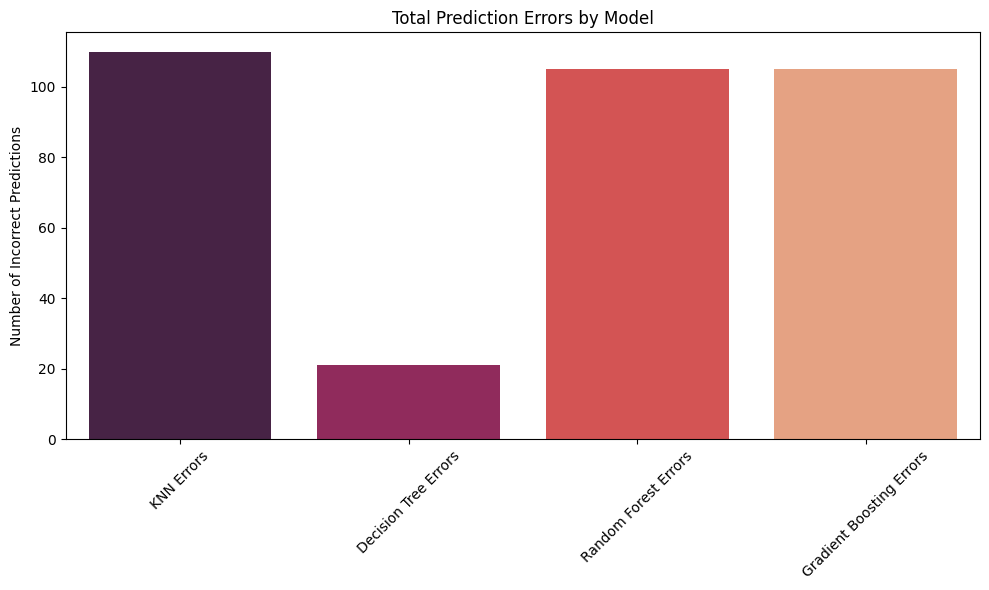

In [46]:
dt_errors = (y_test != dt_pred).sum()
knn_errors = (y_test != knn_pred).sum()
rf_errors = (y_test_dm != rf_dm.predict(X_test_dm)).sum()
gb_errors = (y_test_dm != gb_dm.predict(X_test_dm)).sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=["KNN Errors", "Decision Tree Errors", "Random Forest Errors", "Gradient Boosting Errors"], y=[knn_errors, dt_errors, rf_errors, gb_errors], palette="rocket")
plt.title("Total Prediction Errors by Model")
plt.ylabel("Number of Incorrect Predictions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Prediction Function

In [47]:
def predict_disease(symptom_list):
    """
    Input example:
    ["itching", "skin_rash", "nodal_skin_eruptions"]
    """

    # Create 17-length vector (symptoms) using severity
    input_vector = [0] * 17
    for i, s in enumerate(symptom_list):
        if i < 17:
            input_vector[i] = severity_map.get(s.strip(), 0)

    input_vector = np.array(input_vector).reshape(1, -1)

    # Predictions
    knn_pred_label = le.inverse_transform(knn.predict(input_vector))[0]
    dt_pred_label = le.inverse_transform(dt.predict(input_vector))[0]

    # Use Decision Tree final prediction as main disease
    final_disease = dt_pred_label

    # Get description and precautions
    description = description_map.get(final_disease, "No description available")
    precautions = precaution_map.get(final_disease, ["Not available"])

    return {
        "kNN Prediction": knn_pred_label,
        "Decision Tree Prediction": dt_pred_label,
        "Final Predicted Disease": final_disease,
        "Description": description,
        "Precautions": precautions
    }

# Testing

In [48]:

test_symptoms = ["Stiff Neck", "Headache","Blurred And Distorted Vision"]

result = predict_disease(test_symptoms)
result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


{'kNN Prediction': 'Acne',
 'Decision Tree Prediction': 'Acne',
 'Final Predicted Disease': 'Acne',
 'Description': 'Acne vulgaris is the formation of comedones, papules, pustules, nodules, and/or cysts as a result of obstruction and inflammation of pilosebaceous units (hair follicles and their accompanying sebaceous gland). Acne develops on the face and upper trunk. It most often affects adolescents.',
 'Precautions': ['bath twice',
  'avoid fatty spicy food',
  'drink plenty of water',
  'avoid too many products']}

# Train/Test Split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# Train k-NN Model

In [50]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.9560975609756097


# Train Decision Tree Model

In [51]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=10)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.991869918699187


# Classification Report

In [52]:
print("=== KNN Report ===")
print(classification_report(y_test, knn_pred, target_names=le.classes_))

print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_pred, target_names=le.classes_))

=== KNN Report ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       0.81      1.00      0.89        55
                                   AIDS       1.00      1.00      1.00        57
                                   Acne       1.00      1.00      1.00        62
                    Alcoholic hepatitis       0.96      0.69      0.80        65
                                Allergy       0.79      1.00      0.88        53
                              Arthritis       1.00      0.93      0.96        59
                       Bronchial Asthma       0.95      0.97      0.96        60
                   Cervical spondylosis       0.81      0.93      0.87        59
                            Chicken pox       1.00      1.00      1.00        59
                    Chronic cholestasis       0.76      0.97      0.85        58
                            Common Cold       1.00      1.00      1.00        57
        

# F1 scores

In [53]:
from sklearn.metrics import f1_score

# F1 Score (macro and weighted for multi-class)
knn_f1_macro = f1_score(y_test, knn_pred, average='macro')
dt_f1_macro = f1_score(y_test, dt_pred, average='macro')
rf_f1_macro = f1_score(y_test_dm, rf_dm.predict(X_test_dm), average='macro')
gb_f1_macro = f1_score(y_test_dm, gb_dm.predict(X_test_dm), average='macro')

knn_f1_weighted = f1_score(y_test, knn_pred, average='weighted')
dt_f1_weighted = f1_score(y_test, dt_pred, average='weighted')
rf_f1_weighted = f1_score(y_test_dm, rf_dm.predict(X_test_dm), average='weighted')
gb_f1_weighted = f1_score(y_test_dm, gb_dm.predict(X_test_dm), average='weighted')

print("=== F1 SCORES ===")
print(f"KNN F1 Macro: {knn_f1_macro:.4f}")
print(f"Decision Tree F1 Macro: {dt_f1_macro:.4f}")
print(f"Random Forest F1 Macro: {rf_f1_macro:.4f}")
print(f"Gradient Boosting F1 Macro: {gb_f1_macro:.4f}")

print(f"KNN F1 Weighted: {knn_f1_weighted:.4f}")
print(f"Decision Tree F1 Weighted: {dt_f1_weighted:.4f}")
print(f"Random Forest F1 Weighted: {rf_f1_weighted:.4f}")
print(f"Gradient Boosting F1 Weighted: {gb_f1_weighted:.4f}")

=== F1 SCORES ===
KNN F1 Macro: 0.9566
Decision Tree F1 Macro: 0.9923
Random Forest F1 Macro: 0.8812
Gradient Boosting F1 Macro: 0.8812
KNN F1 Weighted: 0.9561
Decision Tree F1 Weighted: 0.9919
Random Forest F1 Weighted: 0.8770
Gradient Boosting F1 Weighted: 0.8770


# Confusion Matrix

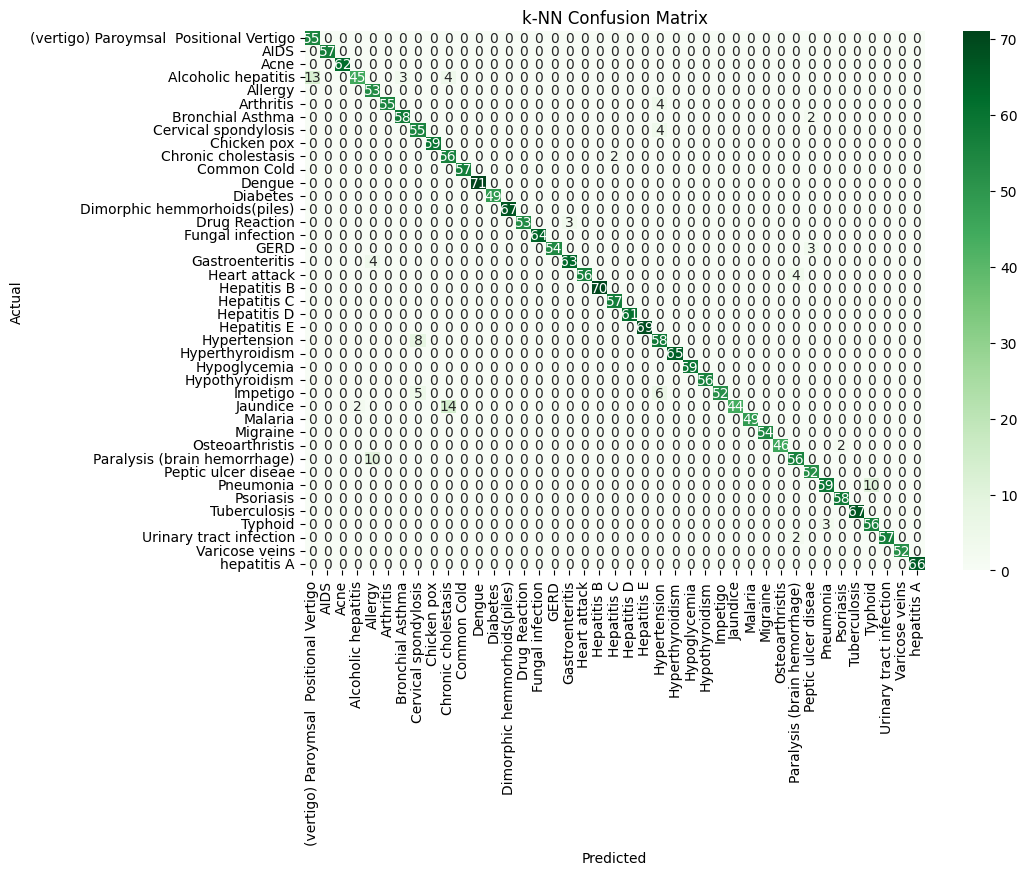

In [54]:
from sklearn.metrics import confusion_matrix

# KNN Confusion Matrix
knn_cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("k-NN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

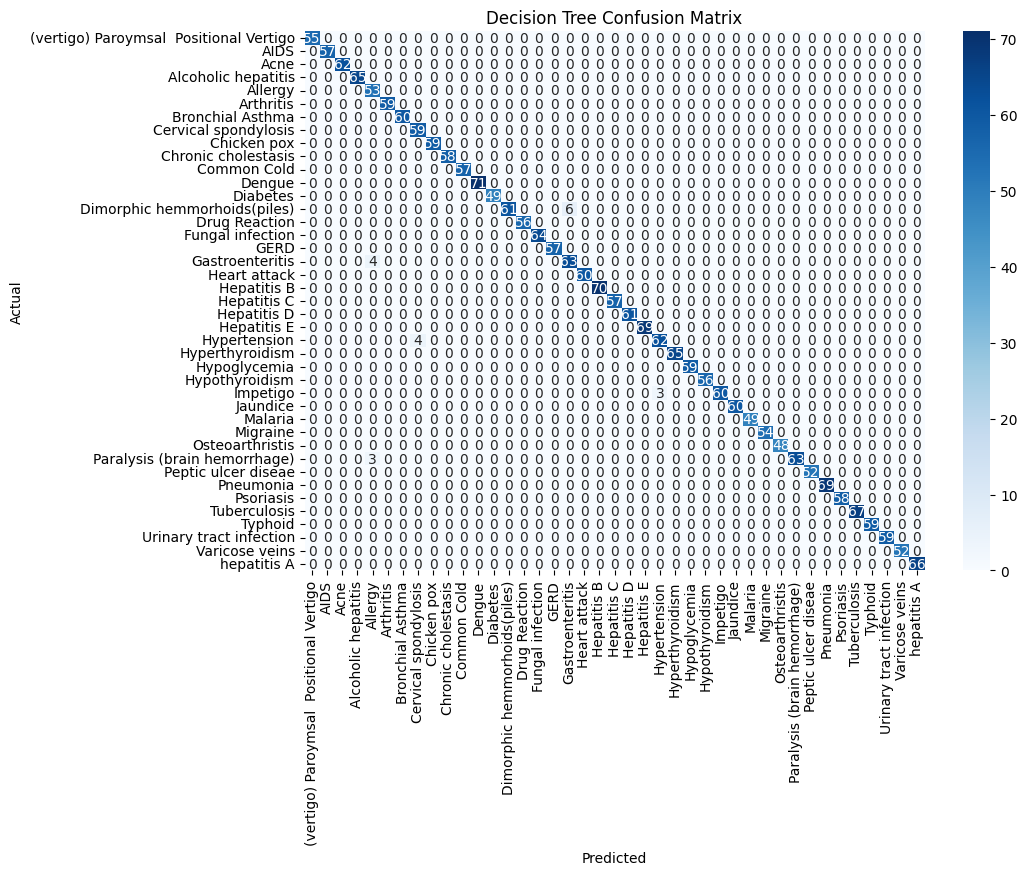

In [55]:
from sklearn.metrics import confusion_matrix

# Decision Tree Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Comparison

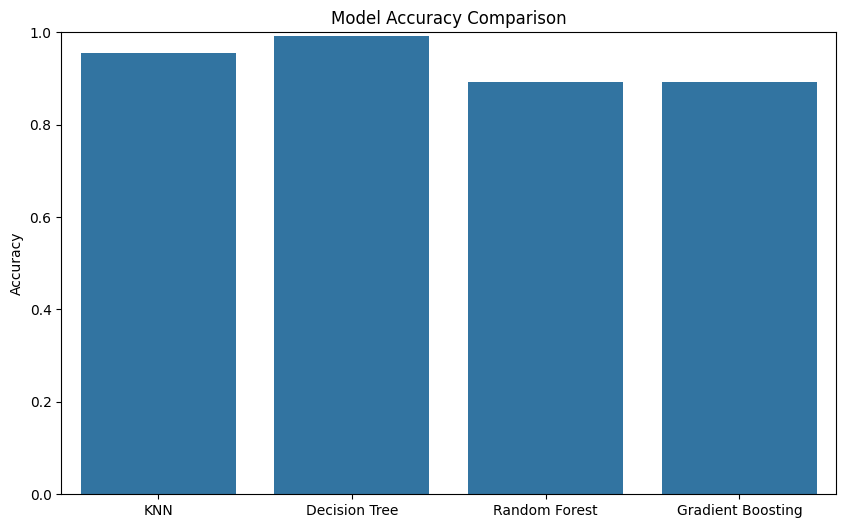

In [56]:
model_names = ["KNN", "Decision Tree", "Random Forest", "Gradient Boosting"]
accuracies = [
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, dt_pred),
    rf_acc,
    gb_acc
]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Accuracy vs F1 Graph

<Figure size 1200x700 with 0 Axes>

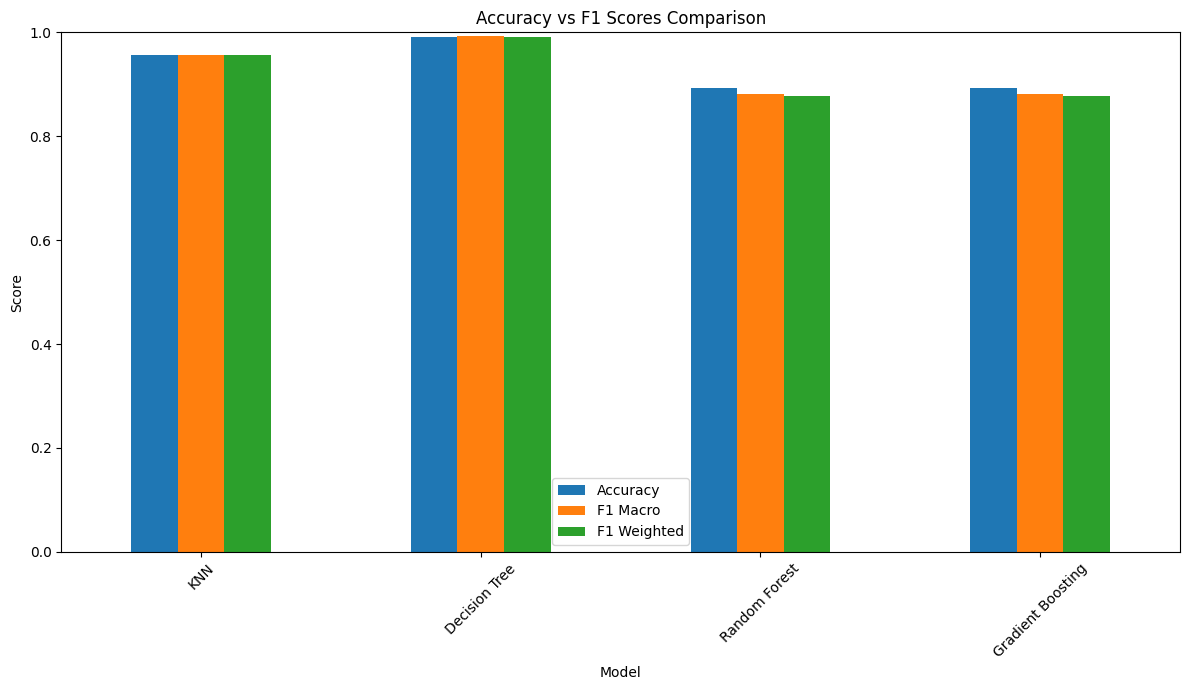

In [57]:
scores_df = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        rf_acc,
        gb_acc
    ],
    "F1 Macro": [knn_f1_macro, dt_f1_macro, rf_f1_macro, gb_f1_macro],
    "F1 Weighted": [knn_f1_weighted, dt_f1_weighted, rf_f1_weighted, gb_f1_weighted]
})

plt.figure(figsize=(12, 7))
scores_df.plot(x="Model", kind="bar", figsize=(12, 7))
plt.title("Accuracy vs F1 Scores Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()